# Soft-Spectral Gentlest Ascent Dynamics (SS-GAD)

## A visual route from ordinary GAD to Competitive Soft-Spectral GAD (CS²-GAD)

<div style="padding: 0.8em 1em; border-left: 5px solid #0072B2; background: #F3F8FB">
<b>Purpose.</b> This notebook explains why each local modification was introduced. It uses an exact four-well surface: no molecule, learned potential, optimizer history, minimum rescue, or hidden acceptance rule.
</div>

The final molecular policy is **Competitive Soft-Spectral GAD (CS²-GAD)**. Its code-level variant is \`competitive_subspace\`; the name identifies its smooth spectral operator and its local competition-aware ascent gate.

## The method evolution: one failure, one local addition

All variants use the same eigenvector-following step introduced below. In the instantaneous vibrational eigenbasis, the only choices are an ascent gate \(w\) and reflection weights \(r_i\):

$$
b_i=(1-2wr_i)c_i.
$$

The simple story and its corresponding local rule are:

| Method | Plain-language rule | Local mathematical change | Failure it addresses |
|---|---|---|---|
| **Ordinary GAD** | Always apply GAD: ascend the lowest mode and descend the rest. | \(w=1,\;r_i=\delta_{i1}\). | Makes an isolated index-1 saddle locally attracting, but can behave poorly far from one. |
| **Descent-then-GAD** | Hard gate: descend with two or more negative modes; use GAD in an index-one-like region. | \(w=\mathbf 1\{\lambda_2>0\},\;r_i=\delta_{i1}\). | High-index / far-from-saddle failures. |
| **Soft-spectral \(\lambda_2\) gate** | Make that descent-to-GAD switch continuous and scale-normalized. | \(w=w_2=\sigma[\lambda_2/(\tau s_H)]\). | Removes the hard switching boundary while retaining the same high-index protection. |
| **Competitive GAD** | Smoothly increase soft-mode ascent when the physical gradient is concentrated in the lowest soft direction, rather than waiting for the descent-then-GAD condition. | \(w=w_2+(1-w_2)\chi,\;r_i=p_i\). | Reduces trajectories accidentally falling into minima during the descent phase. |
| **CS²-GAD** | Use custom soft-subspace reflection when the lowest modes are nearly degenerate. | Same \(w\), but \(r_i=\widetilde p_i=p_i/\max_jp_j\). | Prevents weak or arbitrary soft ascent near degeneracies, another route to minimum capture. |

Every rule remains a deterministic function only of the current coordinates, gradient, and Hessian. “Smoothly increase” is intentional: competitive GAD has a continuous weight, not a new hard trigger.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

plt.rcParams.update({
    "figure.dpi": 115, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "font.size": 10,
})

COLORS = {"ordinary": "#7F7F7F", "lambda2": "#CC79A7", "competitive": "#0072B2", "subspace": "#009E73"}

## 1. An exact four-well landscape

$$
E(x,y)=(x^2-1)^2+(y^2-1)^2.
$$

The origin has two negative Hessian eigenvalues. The points \((0,\pm1)\) and \((\pm1,0)\) are index-1 saddles. The four corners are minima. This is the smallest smooth example that exposes the \(\lambda_2\) issue.

The colored map shows the exact local Morse index. The comparison panels below add each optimizer’s own vector field—not the physical force field.


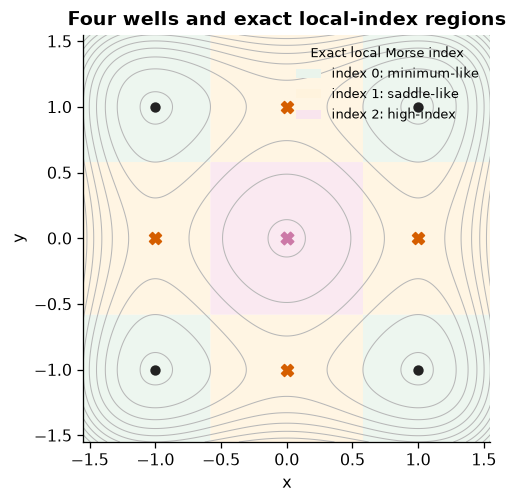

In [2]:
def E(q):
    x, y = q
    return (x*x - 1)**2 + (y*y - 1)**2

def grad(q):
    x, y = q
    return np.array([4*x*(x*x - 1), 4*y*(y*y - 1)], dtype=float)

def hess(q):
    x, y = q
    return np.diag([12*x*x - 4, 12*y*y - 4])

grid = np.linspace(-1.55, 1.55, 300)
X, Y = np.meshgrid(grid, grid)
Z = (X*X - 1)**2 + (Y*Y - 1)**2
# The Hessian is diagonal on this surface, so its exact local Morse index is cheap to show.
INDEX = ((12*X*X - 4) < 0).astype(int) + ((12*Y*Y - 4) < 0).astype(int)
INDEX_CMAP = plt.matplotlib.colors.ListedColormap(["#EAF4EC", "#FFF3DD", "#F9E5EE"])
INDEX_LABELS = ("index 0: minimum-like", "index 1: saddle-like", "index 2: high-index")

def draw_index_background(ax, *, legend=False):
    ax.contourf(X, Y, INDEX, levels=[-.5, .5, 1.5, 2.5], cmap=INDEX_CMAP, alpha=.82, antialiased=True)
    ax.contour(X, Y, Z, levels=np.linspace(.06, 5., 14), colors="#B8B8B8", linewidths=.65)
    if legend:
        from matplotlib.patches import Patch
        ax.legend(
            handles=[Patch(facecolor=INDEX_CMAP(i), edgecolor="none", label=label) for i, label in enumerate(INDEX_LABELS)],
            title="Exact local Morse index", frameon=False, loc="upper right", fontsize=8, title_fontsize=8,
        )

def draw_method_field(ax, vectors, *, n=20, color="white", alpha=.90, width=.004):
    """Draw the raw local method field with one shared linear display scale."""
    field_grid = np.linspace(-1.46, 1.46, n)
    qx, qy = np.meshgrid(field_grid, field_grid)
    points = np.column_stack([qx.ravel(), qy.ravel()])
    updates = np.asarray([vectors(point) for point in points], dtype=float)
    ax.quiver(
        points[:, 0], points[:, 1], updates[:, 0], updates[:, 1],
        angles="xy", scale_units="xy", scale=22, pivot="mid", color=color,
        alpha=alpha, width=width, headwidth=3.0, headlength=3.7, headaxislength=3.3,
        edgecolor="#151515", linewidth=.32, zorder=2,
    )

fig, ax = plt.subplots(figsize=(5.5, 4.6))
draw_index_background(ax, legend=True)
ax.scatter([-1, -1, 1, 1], [-1, 1, -1, 1], c="#222222", s=30, label="minima")
ax.scatter([0, 0, -1, 1], [-1, 1, 0, 0], c="#D55E00", marker="X", s=55, label="index-1 saddles")
ax.scatter([0], [0], c="#CC79A7", marker="X", s=60, label="index-2 centre")
ax.set(xlim=(-1.55, 1.55), ylim=(-1.55, 1.55), aspect="equal", xlabel="x", ylabel="y", title="Four wells and exact local-index regions")
plt.show()


## 2. One common closed-form local step

Diagonalize the current Hessian, \(H=U\Lambda U^T\), and write \(c=U^Tg\). The whole family uses

$$
b_i=(1-2w r_i)c_i,\qquad
\mu=\frac{\|b\|}{R},\qquad
a_i=-\frac{b_i}{\sqrt{\lambda_i^2+\mu^2}},\qquad
q^+=q+Ua.
$$

The toy uses a fixed display radius \(R\). The real method replaces it with the intrinsic, current-geometry pair-distance radius. The difference between methods is only the scalar gate \(w\) and reflection weights \(r_i\).

In [3]:
def sigmoid(z):
    return 1/(1 + np.exp(-np.clip(z, -60, 60)))

@dataclass(frozen=True)
class Policy:
    name: str
    key: str
    competitive: bool = False
    subspace: bool = False

POLICIES = (
    Policy("Ordinary GAD:\nalways reflects one lowest mode", "ordinary"),
    Policy(r"Soft-spectral $\lambda_2$ gate:\ndescends until the region is index-one-like", "lambda2"),
    Policy("Competitive soft-spectral gate:\nactivates ascent when soft activity dominates", "competitive", competitive=True),
    Policy("CS²-GAD:\nprevents soft-subspace reflection dilution", "subspace", competitive=True, subspace=True),
)

def local_quantities(q, tau=.18):
    lam, U = np.linalg.eigh(hess(q))
    c = U.T @ grad(q)
    sH = max(np.sqrt(np.mean(lam**2)), 1e-12)
    z = lam/(tau*sH)
    p = np.exp(-z - np.max(-z)); p /= p.sum()               # soft-min density
    neg = sigmoid(-z)                                        # smooth negative-subspace mask
    w2 = sigmoid(z[1])                                       # smooth lambda_2 gate
    Asoft = np.sum(p*c**2)
    Aextra = np.sum(neg*(1-p)**2*c**2)
    chi = Asoft/(Asoft + Aextra) if Asoft + Aextra > 0 else 0.
    return lam, U, c, p, w2, chi

def step(q, policy, R=.085):
    lam, U, c, p, w2, chi = local_quantities(q)
    if policy.key == "ordinary":
        w, r = 1., np.array([1., 0.])
    else:
        w = w2 + (1-w2)*chi if policy.competitive else w2
        r = p/p.max() if policy.subspace else p
    b = (1 - 2*w*r)*c
    mu = np.linalg.norm(b)/R if np.linalg.norm(b) > 0 else 1.
    return U @ (-b/np.sqrt(lam**2 + mu**2)), {"lambda": lam, "p": p, "w2": w2, "chi": chi, "w": w, "r": r}

def raw_field(q, policy):
    """Unregularized local vector field: the GAD-modified force before step control."""
    lam, U, c, p, w2, chi = local_quantities(q)
    if policy.key == "ordinary":
        w, r = 1., np.array([1., 0.])
    else:
        w = w2 + (1-w2)*chi if policy.competitive else w2
        r = p/p.max() if policy.subspace else p
    b = (1 - 2*w*r)*c
    return U @ (-b)

def trace(start, policy, n=220):
    path = [np.array(start, dtype=float)]
    for _ in range(n): path.append(path[-1] + step(path[-1], policy)[0])
    return np.array(path)

## 3. From high-index descent to an earlier, activity-aware escape

The background is the **exact local Morse index**: pale green is minimum-like (index 0), pale amber is saddle-like (index 1), and pale rose is high index (index 2).

**Descent-then-GAD** fixes the far-from-saddle problem by using the hard rule

$$
w_{\rm hard}=\mathbf 1\{\lambda_2>0\}.
$$

It descends through the rose region and uses GAD only after reaching amber, index-one-like territory. The LJ soft-spectral \(\lambda_2\) gate retains this curvature logic but makes its boundary continuous:

$$
w_2=\sigma\!\left(\frac{\lambda_2}{\tau s_H}\right).
$$

The remaining failure is **minimum capture**: pure descent can fall into a green minimum before it finds an amber corridor. **Competitive GAD** therefore adds a second, independent local signal:

$$
w=w_2+(1-w_2)\chi,
\qquad
\chi=\frac{A_{\rm soft}}{A_{\rm soft}+A_{\rm extra}}.
$$

Here \(A_{\rm soft}\) is physical-gradient activity in the lowest soft direction or soft subspace, and \(A_{\rm extra}\) is activity in the other negative-curvature directions. Thus \(\chi\) can gradually turn on soft-mode ascent before the strict index-one boundary when the gradient identifies one plausible escape. This plot illustrates the mechanism; TS acceptance still requires the final TS and endpoint-topology checks.


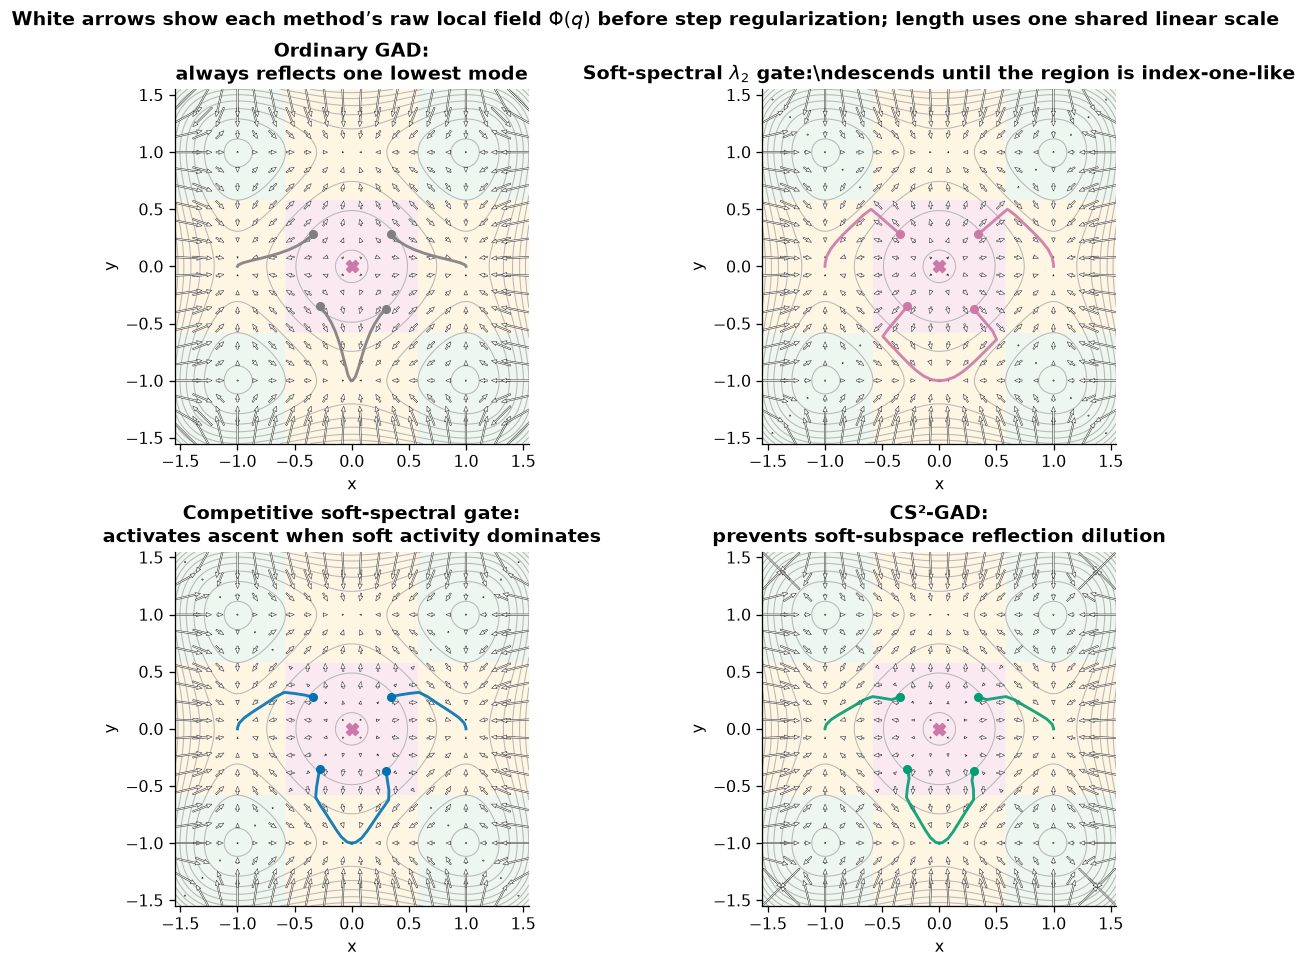

In [4]:
starts = np.array([[.34,.28],[-.34,.28],[.30,-.37],[-.28,-.35]])
fig, axes = plt.subplots(2, 2, figsize=(10.2, 8.3), constrained_layout=True)
for ax, policy in zip(axes.flat, POLICIES):
    draw_index_background(ax)
    draw_method_field(ax, lambda q, policy=policy: raw_field(q, policy))
    for start in starts:
        path = trace(start, policy)
        ax.plot(path[:,0], path[:,1], lw=1.8, color=COLORS[policy.key], alpha=.9)
        ax.scatter(*start, s=22, color=COLORS[policy.key], zorder=3)
    ax.scatter([0], [0], marker="X", s=55, c="#CC79A7", zorder=4)
    ax.set(title=policy.name, xlim=(-1.55,1.55), ylim=(-1.55,1.55), aspect="equal", xlabel="x", ylabel="y")
fig.suptitle("White arrows show each method’s raw local field $\Phi(q)$ before step regularization; length uses one shared linear scale", fontsize=12, fontweight="bold")
plt.show()

## 4. Competitive GAD does more than make descent-to-GAD smoother

The LJ soft-spectral \(\lambda_2\) gate is a smooth version of descent-then-GAD:

$$
w_2=\sigma\!\left(\frac{\lambda_2}{\tau s_H}\right),
\qquad
b_i=(1-2w_2p_i)c_i.
$$

It uses curvature alone: while \(\lambda_2<0\), it prefers descent. Competitive GAD retains that base gate, then adds a local activity signal:

$$
w=w_2+(1-w_2)\chi,
\qquad
\chi=\frac{A_{\rm soft}}{A_{\rm soft}+A_{\rm extra}}.
$$

When the physical gradient is mostly in the lowest soft direction (\(\chi\approx1\)), this smoothly raises the ascent strength even before the strict index-one boundary. Its purpose is simple: avoid letting the descent phase collapse into a minimum before it finds the transition-state region.

The final addition, CS²-GAD, addresses a different remaining problem: what to do when the two lowest modes are so close that selecting one eigenvector is arbitrary.


## 5. CS²-GAD prevents diluted soft ascent at near-degeneracy

Near a degeneracy, the two lowest eigenvalues are close: \(\lambda_1\approx\lambda_2\). There is then no unique “lowest eigenvector” to follow. The competitive soft-spectral gate is still well defined because it uses the analytic soft-min density

$$
p_i=\frac{\exp[-\lambda_i/(\tau s_H)]}
          {\sum_j\exp[-\lambda_j/(\tau s_H)]}.
$$

However, its normalized weights can dilute reflection across tied modes. For example, if two modes are exactly tied, \(p_1=p_2=1/2\); with a fully active gate, \(1-2wp_i=0\), so the intermediate rule cancels descent instead of generating full soft-subspace ascent.

CS²-GAD keeps the same competitive gate. It changes only the reflection density:

$$
r_i=p_i \quad\longrightarrow\quad \widetilde p_i=\frac{p_i}{\max_jp_j}.
$$

Thus tied lowest modes receive equal, full relative reflection when ascent is active. The aim is not to choose between indistinguishable eigenvectors; it is to act consistently on their low-curvature subspace, so weak or arbitrary ascent near a degeneracy does not feed another minimum-capture failure.


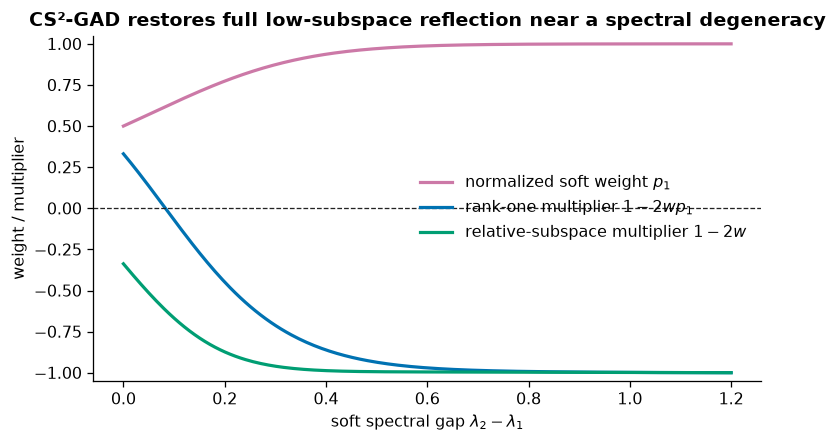

In [5]:
gaps = np.linspace(0, 1.2, 240)
p1, rank_one, relative = [], [], []
for gap in gaps:
    # A two-mode local spectrum with soft-mode-dominated gradient activity.
    lam = np.array([-1., -1.+gap]); sH = np.sqrt(np.mean(lam**2)); z = lam/(.18*sH)
    p = np.exp(-z-np.max(-z)); p /= p.sum()
    c = np.array([1., .05]); neg = sigmoid(-z); w2 = sigmoid(z[1])
    chi = np.sum(p*c*c)/(np.sum(p*c*c)+np.sum(neg*(1-p)**2*c*c))
    w = w2 + (1-w2)*chi
    p1.append(p[0]); rank_one.append(1-2*w*p[0]); relative.append(1-2*w)

fig, ax = plt.subplots(figsize=(7.5,3.9))
ax.plot(gaps,p1,color="#CC79A7",lw=2,label=r"normalized soft weight $p_1$")
ax.plot(gaps,rank_one,color="#0072B2",lw=2,label=r"rank-one multiplier $1-2wp_1$")
ax.plot(gaps,relative,color="#009E73",lw=2,label=r"relative-subspace multiplier $1-2w$")
ax.axhline(0,color="#222222",ls="--",lw=.8)
ax.set(xlabel=r"soft spectral gap $\lambda_2-\lambda_1$",ylabel="weight / multiplier",ylim=(-1.05,1.05),title="CS²-GAD restores full low-subspace reflection near a spectral degeneracy")
ax.legend(frameon=False,ncol=1); plt.show()

## Takeaway: the final local policy is CS²-GAD

<div style="padding: 0.8em 1em; border-left: 5px solid #009E73; background: #F3FBF7">
<b>Competitive Soft-Spectral GAD (CS²-GAD)</b> combines three ideas: descend safely through clear high-index regions; begin a locally justified soft escape before descent falls into a minimum; and reflect a nearly degenerate soft subspace consistently rather than trusting one arbitrary eigenvector.
</div>

An exact rank-one, fully active ordinary-GAD limit is a Householder reflection. Finite-temperature soft-spectral operators generally are not, so “soft-spectral” is the accurate method name. The full derivation and g-xTB results are in \`docs/POINTWISE_INTRINSIC_GAD.md\`.
